# 01 — FDA Backbone and Project Scope

## Purpose
Build a clean exploratory backbone from Drugs@FDA to understand what can be measured for the thesis project.

## Core questions
1. What approval-related variables are available?
2. What should the unit of analysis be?
3. What counts as an approval?
4. Can I create a first-pass controlled-substance indicator?
5. Do preliminary descriptive patterns suggest the project is feasible?

## Inputs
- data/raw/drugsatfda.zip

## Planned outputs
- data/processed/fda_backbone.csv
- output/tables/approvals_by_year.csv
- output/tables/controlled_substance_by_year.csv
- output/figures/approvals_by_year.png
- output/figures/controlled_substance_share_by_year.png

## Caveats
- controlled-substance screening is preliminary unless validated against DEA schedules
- submission dates may be missing, so review duration may not be directly observable

Let's start by setting out paths really quick:

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]   # because notebook is in code/notebooks
DATA = ROOT / "data"
RAW = DATA / "raw"
INTERMEDIATE = DATA / "intermediate"
PROCESSED = DATA / "processed"
OUTPUT = ROOT / "output"
FIGURES = OUTPUT / "figures"
TABLES = OUTPUT / "tables"

for p in [INTERMEDIATE, PROCESSED, FIGURES, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

## FDA Data Source

This project uses the **Drugs@FDA Data Files** provided by the U.S. Food and Drug Administration (FDA).

Source:
https://www.fda.gov/drugs/drug-approvals-and-databases/drugsfda-data-files [accessed Math 14, 2026]

These files provide a structured extract of the Drugs@FDA database and contain information on:

- drug applications (NDA, ANDA, BLA)
- submissions to those applications
- approval actions
- product formulations
- active ingredients
- sponsors / applicants

This dataset is preferred over the monthly approval reports because:

- it provides **structured relational tables**
- it allows **programmatic reproducibility**
- it includes **historical approvals**
- it allows linking between applications, products, and submissions.

### Scope

The Drugs@FDA database primarily covers:

- New Drug Applications (NDA)
- Abbreviated New Drug Applications (ANDA)
- Biologics License Applications (BLA)

However, biologics regulated through the **Center for Biologics Evaluation and Research (CBER)** may not appear in the same way as small-molecule drugs regulated by **CDER**.

### Download Information

Download date: `YYYY-MM-DD`

Downloaded file:

```
data/raw/drugsatfda.zip
```

The contents of this archive will be inspected and loaded in the next step.

In [5]:
zip_path = RAW / "dafdata20260313.zip"

print("Zip file exists:", zip_path.exists())
print("Location:", zip_path)

with zipfile.ZipFile(zip_path, "r") as z:
    file_list = z.namelist()

file_list

Zip file exists: True
Location: /Users/alexdelatorre/Desktop/econ580-thesis/data/raw/dafdata20260313.zip


['ActionTypes_Lookup.txt',
 'ApplicationDocs.txt',
 'Applications.txt',
 'ApplicationsDocsType_Lookup.txt',
 'Join_Submission_ActionTypes_Lookup.txt',
 'MarketingStatus.txt',
 'MarketingStatus_Lookup.txt',
 'Products.txt',
 'SubmissionClass_Lookup.txt',
 'SubmissionPropertyType.txt',
 'Submissions.txt',
 'TE.txt']

Let's extract explicitly unpack the dataset so the repo is transparent.

In [6]:
extract_dir = RAW / "dafdata20260313"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: /Users/alexdelatorre/Desktop/econ580-thesis/data/raw/dafdata20260313


### Schema Audit

The following table descriptions and join strategy were generated after an automated
inspection of the extracted Drugs@FDA files using Codex. The summary reflects the
actual row counts and column structures present in the local snapshot downloaded on
2026-03-14.

These notes serve as a reference while constructing the FDA approval backbone dataset.
All conclusions about which tables are used in the analysis are verified manually
in the subsequent cells.

## 1. Dataset Overview

The extracted **Drugs@FDA** files form a relational administrative dataset describing FDA drug applications, their regulatory submissions, approved products, marketing status, therapeutic equivalence, and linked approval documents.

A useful way to think about the structure is:

- **Application level**: one FDA application (`ApplNo`) in `Applications`
- **Submission level**: one original application or supplement (`ApplNo`, `SubmissionType`, `SubmissionNo`) in `Submissions`
- **Product level**: one marketed product under an application (`ApplNo`, `ProductNo`) in `Products`

For approval analysis, the backbone is usually:

- `Applications` for application identity
- `Submissions` for approval events and dates
- `SubmissionClass_Lookup` for regulatory classification
- `Products` for the actual drug/product attached to the application

Most other tables are supporting metadata that enrich submissions, products, or documents.

---

## 2. Table Dictionary

| Table | Unit of Observation | Primary Key(s) | Important Fields | Role |
|---|---|---|---|---|
| `Applications.txt` | One FDA application | `ApplNo` | `ApplType`, `SponsorName`, `ApplPublicNotes` | **CORE** |
| `Submissions.txt` | One submission within an application | `ApplNo`, `SubmissionType`, `SubmissionNo` | `SubmissionClassCodeID`, `SubmissionStatus`, `SubmissionStatusDate`, `ReviewPriority`, `SubmissionsPublicNotes` | **CORE** |
| `Products.txt` | One product within an application | `ApplNo`, `ProductNo` | `DrugName`, `ActiveIngredient`, `Form`, `Strength`, `ReferenceDrug`, `ReferenceStandard` | **CORE** |
| `SubmissionClass_Lookup.txt` | One submission class code | `SubmissionClassCodeID` | `SubmissionClassCode`, `SubmissionClassCodeDescription` | **CORE** |
| `MarketingStatus.txt` | One product marketing-status record | `ApplNo`, `ProductNo` | `MarketingStatusID` | Supporting |
| `MarketingStatus_Lookup.txt` | One marketing status code | `MarketingStatusID` | `MarketingStatusDescription` | Supporting |
| `TE.txt` | One therapeutic equivalence record for a product | not strictly unique on `ApplNo`, `ProductNo` | `ApplNo`, `ProductNo`, `MarketingStatusID`, `TECode` | Supporting |
| `SubmissionPropertyType.txt` | One property attached to a submission | no clean single-row submission key; multiple rows per submission | `SubmissionPropertyTypeCode`, `SubmissionPropertyTypeID` | Supporting |
| `Join_Submission_ActionTypes_Lookup.txt` | One action-type assignment to a submission | `j_submissionActionTypeID` | `ApplNo`, `SubmissionType`, `SubmissionNo`, `ActionTypes_LookupID` | Supporting |
| `ActionTypes_Lookup.txt` | One action type code | `ActionTypes_LookupID` | `ActionTypes_LookupDescription`, `SupplCategoryLevel1Code`, `SupplCategoryLevel2Code` | Supporting |
| `ApplicationDocs.txt` | One linked FDA document | `ApplicationDocsID` | `ApplicationDocsTypeID`, `ApplNo`, `SubmissionType`, `SubmissionNo`, `ApplicationDocsTitle`, `ApplicationDocsURL`, `ApplicationDocsDate` | Supporting |
| `ApplicationsDocsType_Lookup.txt` | One document type code | `ApplicationDocsType_Lookup_ID` | `ApplicationDocsType_Lookup_Description` | Supporting |

### Notes on analytic importance

- For a clean **approval-event dataset**, start from `Submissions` and enrich with `Applications`, `SubmissionClass_Lookup`, and optionally `Products`.
- `Products` is core for drug identity, but note that approvals are fundamentally recorded at the **submission** level, not the product row level.
- `MarketingStatus`, `TE`, `ActionTypes`, and `ApplicationDocs` are best treated as enrichment tables, not as the backbone.

---

## 3. Recommended Join Strategy

### Goal

Construct an approval-oriented dataset where each row represents an FDA approval event, then attach application- and product-level context.

### Recommended core join order

1. **Start with `Submissions`**
   - This is the main event table for approval analysis.
   - Filter to approval-relevant rows using:
     - `SubmissionStatus == "AP"` for approved submissions
     - `SubmissionType` to distinguish original approvals (`ORIG`) from supplements (`SUPPL`)

2. **Join `SubmissionClass_Lookup`**
   - Join key: `SubmissionClassCodeID`
   - Purpose: decode regulatory class (`TYPE 1`, `TYPE 3`, `TYPE 5`, `REMS`, `BIOSIMILAR`, etc.)
   - This is essential for interpreting what kind of approval/submission event occurred.

3. **Join `Applications`**
   - Join key: `ApplNo`
   - Purpose: add application type (`NDA`, `ANDA`, `BLA`) and sponsor information
   - This supplies the application-level identity and is the natural parent table for submissions.

4. **Join `Products`**
   - Join key: `ApplNo`
   - Purpose: add drug/product identity (`DrugName`, `ActiveIngredient`, `Form`, `Strength`)
   - Important caveat: this is a **one-to-many** join because one application can have multiple products.
   - Use this join only after deciding the intended final unit:
     - **Submission-level approval dataset**: join carefully or aggregate product info first
     - **Product-level approval dataset**: expand submissions across products within application

### Optional enrichment joins

- **`MarketingStatus`** on `ApplNo`, `ProductNo`
  - Use after joining `Products`
  - Adds whether a product is prescription, OTC, discontinued, tentative approval, etc.

- **`MarketingStatus_Lookup`** on `MarketingStatusID`
  - Decodes marketing status labels

- **`TE`** on `ApplNo`, `ProductNo`
  - Use only when therapeutic equivalence is relevant
  - Not all products appear; some products have multiple TE rows

- **`Join_Submission_ActionTypes_Lookup`** on `ApplNo`, trimmed `SubmissionType`, `SubmissionNo`
  - Use for supplement classification or more granular action-type analysis

- **`ActionTypes_Lookup`** on `ActionTypes_LookupID`
  - Decodes action categories such as labeling, efficacy, manufacturing/CMC, REMS

- **`ApplicationDocs`** on `ApplNo`, trimmed `SubmissionType`, `SubmissionNo`
  - Use to attach links to letters, labels, reviews, REMS documents, etc.
  - This is document metadata, not the underlying text content

### Practical interpretation

For most approval analyses, the safest backbone is:

`Submissions`  
→ `SubmissionClass_Lookup` on `SubmissionClassCodeID`  
→ `Applications` on `ApplNo`  
→ `Products` on `ApplNo` only if product-level expansion is intended

---

## 4. Data Quality Notes

### Encoding

- Most files are UTF-8 with BOM.
- `Submissions.txt` and `ApplicationDocs.txt` required **Latin-1** fallback during inspection.
- Cleaning should allow for non-UTF-8 characters rather than assuming uniform encoding.

### Zero-padded identifiers

- `ApplNo`, `ProductNo`, and `SubmissionNo` should be treated as **strings**, not numeric fields.
- Leading zeros are meaningful and required for correct joins.

### Placeholder dates

- Dates are stored as timestamps like `YYYY-MM-DD 00:00:00`.
- `1900-01-01 00:00:00` appears as a placeholder in at least some rows and should not automatically be treated as a real event date.

### Imperfect referential integrity

- The extract is not perfectly closed under all joins.
- Some application numbers in `Submissions` or `Products` do not appear in `Applications`.
- Some `MarketingStatus`, `TE`, `ActionTypes`, `SubmissionPropertyType`, and `ApplicationDocs` records do not map cleanly back to a parent row.
- This means missing joins should be interpreted cautiously, not automatically as data entry error in your pipeline.

### Partial coverage tables

- `TE.txt` is a **subset** table, not a complete product inventory.
- `ApplicationDocs.txt` is a **document metadata** table, not a complete representation of all approvals or all documents.
- `MarketingStatus` and `TE` should not be used to define the universe of approvals.

### Fields requiring caution

- `SubmissionPropertyTypeCode` is mostly literal `Null`; `SubmissionPropertyTypeID` appears to contain additional information, but no lookup table was present in this extract.
- `ReviewPriority` contains blanks, `UNKNOWN`, `N/A`, and other nonstandard values.
- `ActionTypes_Lookup` contains duplicated labels, blank descriptions, and low-information codes.
- `SubmissionType` is inconsistently padded across files and should be trimmed before joining.
- `ApplicationDocs` includes `SubmissionType = APPL`, which does not align directly with the `Submissions` table and should be handled separately.

### Bottom line

For a clean approval dataset, rely primarily on `Submissions` plus `Applications` and `SubmissionClass_Lookup`, and treat product-, document-, and action-level tables as enrichment layers added only after the analytic unit is clearly defined.


Okay now with a clearer view of the data, let's load the core tables---the main 4 'backbone' tables for our analysis

In [ ]:
applications = pd.read_csv(
    extract_dir / "Applications.txt",
    sep="\t",
    dtype=str
)

submissions = pd.read_csv(
    extract_dir / "Submissions.txt",
    sep="\t",
    dtype=str,
    encoding="latin-1"
)

products = pd.read_csv(
    extract_dir / "Products.txt",
    sep="\t",
    dtype=str
)

submission_class = pd.read_csv(
    extract_dir / "SubmissionClass_Lookup.txt",
    sep="\t",
    dtype=str
)

Now lets iinspect the structure of these tables and shape...

In [ ]:
applications.shape
submissions.shape
products.shape
submission_class.shape

submissions.head()
submissions["SubmissionStatus"].value_counts()

SubmissionStatus
AP    190051
TA      1213
Name: count, dtype: int64

Now let's also identify the actual approval events by filtering the submissions table...

In [12]:
approved = submissions[submissions["SubmissionStatus"] == "AP"].copy()
# Check the shape:
approved.shape
# Now we inspect the submission types:
approved["SubmissionType"].value_counts()

SubmissionType
SUPPL    163783
ORIG      26268
Name: count, dtype: int64

So ORIG corresponds to the first approval of a drug application where as SUPPL are supplements, which I thimk represent later changes to that original drug.

Well, let's create a clean approval set:

In [20]:
orig_approvals = approved[approved["SubmissionType"] == "ORIG"].copy()

# Inspect the ORIG approvals:
orig_approvals.shape

(26268, 8)

And let's see the head of ORIG Approvals:

In [19]:
orig_approvals.head()

,ApplNo,SubmissionClassCodeID,SubmissionType,SubmissionNo,SubmissionStatus,SubmissionStatusDate,SubmissionsPublicNotes,ReviewPriority
0,000004,19,ORIG,1,AP,1969-07-16 00:00:00,NaN,UNKNOWN
3,000159,NaN,ORIG,1,AP,1939-03-09 00:00:00,NaN,NaN
6,000415,NaN,ORIG,1,AP,1939-02-27 00:00:00,NaN,NaN
7,000552,19,ORIG,1,AP,1939-02-09 00:00:00,NaN,UNKNOWN
24,000654,19,ORIG,1,AP,1939-05-04 00:00:00,NaN,UNKNOWN


We convert the Approval date to a date from a srting:

In [21]:
orig_approvals["SubmissionStatusDate"] = pd.to_datetime(
    orig_approvals["SubmissionStatusDate"],
    errors="coerce"
)

orig_approvals["approval_year"] = orig_approvals["SubmissionStatusDate"].dt.year

Now we inspect the `approval_year` date:

In [22]:
orig_approvals["approval_year"].describe()

count    26267.000000
mean      2003.244832
std         17.974398
min       1900.000000
25%       1989.000000
50%       2008.000000
75%       2018.000000
max       2026.000000
Name: approval_year, dtype: float64

In [23]:
orig_approvals["approval_year"].value_counts().sort_index().tail(20)

approval_year
2007.0    567
2008.0    561
2009.0    553
2010.0    519
2011.0    547
2012.0    603
2013.0    572
2014.0    539
2015.0    696
2016.0    718
2017.0    990
2018.0    971
2019.0    962
2020.0    886
2021.0    754
2022.0    870
2023.0    906
2024.0    853
2025.0    824
2026.0    166
Name: count, dtype: int64

Quick sanity check: check the timeline:

In [26]:
orig_approvals.groupby("approval_year").size().tail(30)

approval_year
1997.0    400
1998.0    331
1999.0    270
2000.0    348
2001.0    298
2002.0    415
2003.0    340
2004.0    492
2005.0    422
2006.0    467
2007.0    567
2008.0    561
2009.0    553
2010.0    519
2011.0    547
2012.0    603
2013.0    572
2014.0    539
2015.0    696
2016.0    718
2017.0    990
2018.0    971
2019.0    962
2020.0    886
2021.0    754
2022.0    870
2023.0    906
2024.0    853
2025.0    824
2026.0    166
dtype: int64

### Join Application Metadata
Now we attach application-level metadata:

In [27]:
approvals = orig_approvals.merge(
    applications,
    on="ApplNo",
    how="left"
)

Now we inspect that `ApplType`:

In [28]:
approvals["ApplType"].value_counts()

ApplType
ANDA    19303
NDA      5330
BLA       482
Name: count, dtype: int64

So look at that! The vast majority of the drug approvals that come into the FDA are ANDA's, or [Abbreviated New Drug Applications](https://www.fda.gov/drugs/types-applications/abbreviated-new-drug-application-anda), which are for new generic products, which is consistent with the narrative ['Bottle of Lies' by Katherine Eban](https://www.amazon.com/Bottle-Lies-Inside-Story-Generic/dp/0062338781) (great read). 

I am curious when did this explosion of generic products begin [ANDAs] because that might be at least tangentially relevant to what we might do or at least be something we control for.

Anyways, let's just attach the drug identity to this:

In [30]:
approvals = approvals.merge(
    products[["ApplNo","DrugName","ActiveIngredient"]],
    on="ApplNo",
    how="left"
)

approvals.head()

,ApplNo,SubmissionClassCodeID,SubmissionType,SubmissionNo,SubmissionStatus,SubmissionStatusDate,SubmissionsPublicNotes,ReviewPriority,approval_year,ApplType,ApplPublicNotes,SponsorName,DrugName_x,ActiveIngredient_x,DrugName_y,ActiveIngredient_y
0,000004,19,ORIG,1,AP,1969-07-16,NaN,UNKNOWN,1969.0,NDA,NaN,PHARMICS,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE
1,000159,NaN,ORIG,1,AP,1939-03-09,NaN,NaN,1939.0,NDA,NaN,LILLY,SULFAPYRIDINE,SULFAPYRIDINE,SULFAPYRIDINE,SULFAPYRIDINE
2,000415,NaN,ORIG,1,AP,1939-02-27,NaN,NaN,1939.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000552,19,ORIG,1,AP,1939-02-09,NaN,UNKNOWN,1939.0,NDA,NaN,ASPEN GLOBAL INC,LIQUAEMIN SODIUM,HEPARIN SODIUM,LIQUAEMIN SODIUM,HEPARIN SODIUM
4,000552,19,ORIG,1,AP,1939-02-09,NaN,UNKNOWN,1939.0,NDA,NaN,ASPEN GLOBAL INC,LIQUAEMIN SODIUM,HEPARIN SODIUM,LIQUAEMIN SODIUM,HEPARIN SODIUM


## Approval time series
First descriptive result!

<Axes: xlabel='approval_year'>

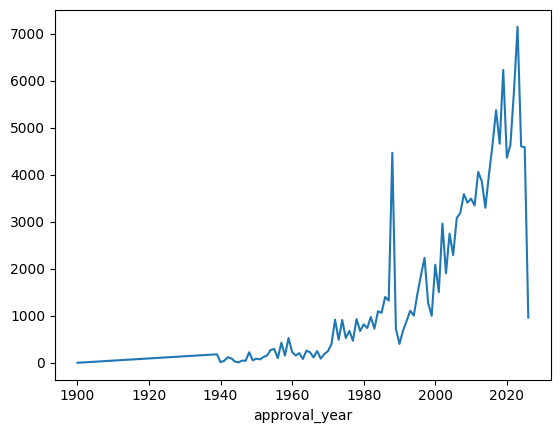

In [ ]:
approvals_by_year = approvals.groupby("approval_year").size()

approvals_by_year.plot()

look at that post 1992 growth!

Now lets investigate the priority review applications overtime

In [32]:
approvals["ReviewPriority"].value_counts()

ReviewPriority
STANDARD    70452
PRIORITY     8392
UNKNOWN      1061
Name: count, dtype: int64

<Axes: xlabel='approval_year'>

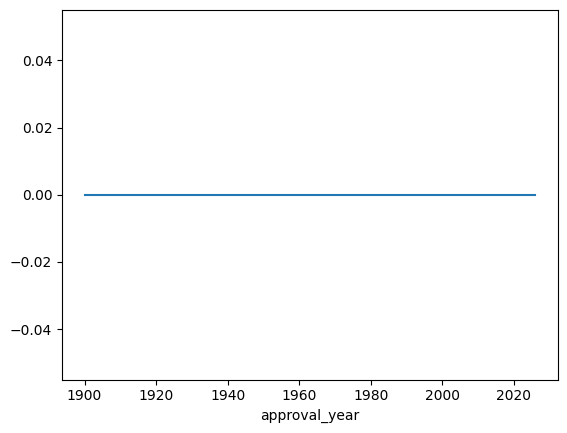

In [34]:
priority_share = (
    approvals.groupby("approval_year")["ReviewPriority"]
    .apply(lambda x: (x == "Priority").mean())
)

priority_share.plot()

## Conservative First-Pass Approval Backbone

The next cells rebuild the FDA approval backbone in a more careful way for exploratory analysis.

They:
- treat the **submission event** as the starting unit of observation
- define full approvals conservatively as `SubmissionStatus == "AP"`
- keep `ORIG` approvals separate as the main first-pass subset
- merge only the core tables (`Submissions`, `Applications`, `Products`, `SubmissionClass_Lookup`)
- aggregate product fields to the **application level** before merging so product rows do not inflate approval counts
- standardize `ReviewPriority` and `ApplType` conservatively
- parse approval dates, treat placeholder dates as missing, and print diagnostic summaries

Important caveat: `DrugName` and `ActiveIngredient` below are **application-level descriptors aggregated from `Products.txt`**, not exact submission-to-product matches.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().resolve().parents[1]
RAW_FDA = ROOT / "data" / "raw" / "dafdata20260313"

def read_fda_table(path: Path) -> pd.DataFrame:
    last_error = None
    for enc in ("utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, sep="\t", dtype=str, encoding=enc)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error

def clean_string_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )

def collapse_unique(values):
    ordered = []
    seen = set()
    for value in pd.Series(list(values), dtype="string").dropna():
        value = value.strip()
        if value and value not in seen:
            ordered.append(value)
            seen.add(value)
    return "; ".join(ordered) if ordered else pd.NA

def standardize_review_priority(s: pd.Series) -> pd.Series:
    raw = clean_string_series(s).str.upper()
    out = pd.Series("OTHER", index=s.index, dtype="string")
    out.loc[raw.isna() | raw.isin(["UNKNOWN", "N/A"])] = "UNKNOWN"
    out.loc[raw.eq("STANDARD")] = "STANDARD"
    out.loc[raw.eq("PRIORITY")] = "PRIORITY"
    return out

def standardize_appl_type(s: pd.Series) -> pd.Series:
    raw = clean_string_series(s).str.upper()
    out = pd.Series("OTHER", index=s.index, dtype="string")
    out.loc[raw.isna()] = "UNKNOWN"
    out.loc[raw.isin(["NDA", "ANDA", "BLA"])] = raw[raw.isin(["NDA", "ANDA", "BLA"])]
    return out

applications = read_fda_table(RAW_FDA / "Applications.txt")
submissions = read_fda_table(RAW_FDA / "Submissions.txt")
products = read_fda_table(RAW_FDA / "Products.txt")
submission_class_lookup = read_fda_table(RAW_FDA / "SubmissionClass_Lookup.txt")


In [4]:
for df in [applications, submissions, products, submission_class_lookup]:
    for col in df.columns:
        df[col] = clean_string_series(df[col])

submissions["SubmissionType"] = submissions["SubmissionType"].str.upper()
submissions["SubmissionStatus"] = submissions["SubmissionStatus"].str.upper()
applications["ApplType"] = applications["ApplType"].str.upper()

print("Core table shapes")
print({
    "applications": applications.shape,
    "submissions": submissions.shape,
    "products": products.shape,
    "submission_class_lookup": submission_class_lookup.shape,
})

print("\nApplications columns")
print(applications.columns.tolist())

print("\nSubmissions columns")
print(submissions.columns.tolist())

print("\nProducts columns")
print(products.columns.tolist())

print("\nRaw SubmissionStatus counts")
print(submissions["SubmissionStatus"].value_counts(dropna=False))

print("\nRaw SubmissionType counts")
print(submissions["SubmissionType"].value_counts(dropna=False))

print("\nRaw ApplType counts")
print(applications["ApplType"].value_counts(dropna=False))


Core table shapes
{'applications': (28923, 4), 'submissions': (191265, 8), 'products': (50899, 8), 'submission_class_lookup': (28, 3)}

Applications columns
['ApplNo', 'ApplType', 'ApplPublicNotes', 'SponsorName']

Submissions columns
['ApplNo', 'SubmissionClassCodeID', 'SubmissionType', 'SubmissionNo', 'SubmissionStatus', 'SubmissionStatusDate', 'SubmissionsPublicNotes', 'ReviewPriority']

Products columns
['ApplNo', 'ProductNo', 'Form', 'Strength', 'ReferenceDrug', 'DrugName', 'ActiveIngredient', 'ReferenceStandard']

Raw SubmissionStatus counts
SubmissionStatus
AP      190051
TA        1213
<NA>         1
Name: count, dtype: int64[pyarrow]

Raw SubmissionType counts
SubmissionType
SUPPL    163831
ORIG      27434
Name: count, dtype: int64[pyarrow]

Raw ApplType counts
ApplType
ANDA    22626
NDA      5832
BLA       465
Name: count, dtype: int64[pyarrow]


In [5]:
product_summary = (
    products.sort_values(["ApplNo", "ProductNo"])
    .groupby("ApplNo", dropna=False)
    .agg(
        n_products=("ProductNo", "nunique"),
        ProductNo_list=("ProductNo", collapse_unique),
        DrugName=("DrugName", collapse_unique),
        ActiveIngredient=("ActiveIngredient", collapse_unique),
    )
    .reset_index()
)

submission_events = (
    submissions
    .merge(
        applications[["ApplNo", "ApplType", "SponsorName"]],
        on="ApplNo",
        how="left",
        validate="m:1",
    )
    .merge(
        submission_class_lookup[["SubmissionClassCodeID", "SubmissionClassCode", "SubmissionClassCodeDescription"]],
        on="SubmissionClassCodeID",
        how="left",
        validate="m:1",
    )
    .merge(
        product_summary,
        on="ApplNo",
        how="left",
        validate="m:1",
    )
    .copy()
)

submission_events["ReviewPriority_raw"] = submission_events["ReviewPriority"]
submission_events["ApplType_raw"] = submission_events["ApplType"]
submission_events["SubmissionStatusDate_raw"] = submission_events["SubmissionStatusDate"]

submission_events["ReviewPriority"] = standardize_review_priority(submission_events["ReviewPriority"])
submission_events["ApplType"] = standardize_appl_type(submission_events["ApplType"])

submission_events["SubmissionStatusDate"] = pd.to_datetime(
    submission_events["SubmissionStatusDate"],
    errors="coerce",
)

placeholder_date = pd.Timestamp("1900-01-01")
placeholder_mask = submission_events["SubmissionStatusDate"] == placeholder_date
submission_events.loc[placeholder_mask, "SubmissionStatusDate"] = pd.NaT
submission_events["approval_year"] = submission_events["SubmissionStatusDate"].dt.year.astype("Int64")

print("Merged submission-event rows:", len(submission_events))
print("Raw submissions rows:", len(submissions))
print("Duplicate submission-event keys after merge:", submission_events.duplicated(
    subset=["ApplNo", "SubmissionType", "SubmissionNo"]
).sum())
print("Placeholder 1900-01-01 dates set to missing:", int(placeholder_mask.sum()))

display(product_summary.head())


Merged submission-event rows: 191265
Raw submissions rows: 191265
Duplicate submission-event keys after merge: 0
Placeholder 1900-01-01 dates set to missing: 1


,ApplNo,n_products,ProductNo_list,DrugName,ActiveIngredient
0,000004,1,004,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE
1,000159,1,001,SULFAPYRIDINE,SULFAPYRIDINE
2,000552,12,001; 002; 003; 004; 005; 007; 008; 009; 010; 0...,LIQUAEMIN SODIUM; LIQUAEMIN LOCK FLUSH; HEPARI...,HEPARIN SODIUM
3,000734,3,001; 002; 003,HISTAMINE PHOSPHATE,HISTAMINE PHOSPHATE
4,000793,4,002; 003; 004; 005,BUTISOL SODIUM,BUTABARBITAL SODIUM


In [6]:
approval_backbone = submission_events.loc[submission_events["SubmissionStatus"].eq("AP")].copy()
tentative_submissions = submission_events.loc[submission_events["SubmissionStatus"].eq("TA")].copy()
orig_approvals = approval_backbone.loc[approval_backbone["SubmissionType"].eq("ORIG")].copy()

final_cols = [
    "ApplNo",
    "SubmissionType",
    "SubmissionNo",
    "SubmissionStatus",
    "SubmissionStatusDate",
    "approval_year",
    "ReviewPriority_raw",
    "ReviewPriority",
    "ApplType_raw",
    "ApplType",
    "SponsorName",
    "DrugName",
    "ActiveIngredient",
    "n_products",
    "ProductNo_list",
    "SubmissionClassCodeID",
    "SubmissionClassCode",
    "SubmissionClassCodeDescription",
]

approval_backbone = approval_backbone[final_cols].copy()
tentative_submissions = tentative_submissions[final_cols].copy()
orig_approvals = orig_approvals[final_cols].copy()

print("approval_backbone rows (AP only):", len(approval_backbone))
print("tentative_submissions rows (TA only):", len(tentative_submissions))
print("orig_approvals rows (AP + ORIG):", len(orig_approvals))

print("\nRecommended use")
print("- Use `approval_backbone` for all full approval events at the submission level.")
print("- Use `orig_approvals` for first-pass descriptive analysis of original approvals.")


approval_backbone rows (AP only): 190051
tentative_submissions rows (TA only): 1213
orig_approvals rows (AP + ORIG): 26268

Recommended use
- Use `approval_backbone` for all full approval events at the submission level.
- Use `orig_approvals` for first-pass descriptive analysis of original approvals.


In [7]:
def missingness_table(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = pd.DataFrame({
        "missing_n": df[cols].isna().sum(),
        "missing_share": df[cols].isna().mean().round(4),
    })
    return out.sort_values(["missing_share", "missing_n"], ascending=False)

print("Row counts")
print({
    "submission_events": len(submission_events),
    "approval_backbone_AP_only": len(approval_backbone),
    "tentative_submissions_TA_only": len(tentative_submissions),
    "orig_approvals_AP_ORIG_only": len(orig_approvals),
})

print("\nSubmissionType counts (AP only)")
print(approval_backbone["SubmissionType"].value_counts(dropna=False))

print("\nSubmissionType counts (ORIG-only subset)")
print(orig_approvals["SubmissionType"].value_counts(dropna=False))

print("\nReviewPriority counts (AP only, cleaned)")
print(approval_backbone["ReviewPriority"].value_counts(dropna=False))

print("\nReviewPriority counts (ORIG-only subset, cleaned)")
print(orig_approvals["ReviewPriority"].value_counts(dropna=False))

print("\nApplType counts (AP only, cleaned)")
print(approval_backbone["ApplType"].value_counts(dropna=False))

print("\nApplType counts (ORIG-only subset, cleaned)")
print(orig_approvals["ApplType"].value_counts(dropna=False))

ap_years = approval_backbone["approval_year"].dropna()
orig_years = orig_approvals["approval_year"].dropna()

print("\nApproval year range (AP only)")
print({
    "min_year": int(ap_years.min()) if len(ap_years) else None,
    "max_year": int(ap_years.max()) if len(ap_years) else None,
})

print("\nApproval year range (ORIG-only subset)")
print({
    "min_year": int(orig_years.min()) if len(orig_years) else None,
    "max_year": int(orig_years.max()) if len(orig_years) else None,
})

key_cols = [
    "ApplNo",
    "SubmissionType",
    "SubmissionNo",
    "SubmissionStatusDate",
    "approval_year",
    "ReviewPriority",
    "ApplType",
    "SponsorName",
    "DrugName",
    "ActiveIngredient",
    "SubmissionClassCodeID",
    "SubmissionClassCode",
]

print("\nMissingness in key fields (AP only)")
display(missingness_table(approval_backbone, key_cols))

print("\nMissingness in key fields (ORIG-only subset)")
display(missingness_table(orig_approvals, key_cols))

print("\nDuplicate key check")
print({
    "approval_backbone_duplicates": int(
        approval_backbone.duplicated(["ApplNo", "SubmissionType", "SubmissionNo"]).sum()
    ),
    "orig_approvals_duplicates": int(
        orig_approvals.duplicated(["ApplNo", "SubmissionType", "SubmissionNo"]).sum()
    ),
})

print("\nSample rows from orig_approvals")
display(orig_approvals.head(10))


Row counts
{'submission_events': 191265, 'approval_backbone_AP_only': 190051, 'tentative_submissions_TA_only': 1213, 'orig_approvals_AP_ORIG_only': 26268}

SubmissionType counts (AP only)
SubmissionType
SUPPL    163783
ORIG      26268
Name: count, dtype: int64[pyarrow]

SubmissionType counts (ORIG-only subset)
SubmissionType
ORIG    26268
Name: count, dtype: int64[pyarrow]

ReviewPriority counts (AP only, cleaned)
ReviewPriority
STANDARD    92815
UNKNOWN     85225
PRIORITY    11049
OTHER         962
Name: count, dtype: int64[pyarrow]

ReviewPriority counts (ORIG-only subset, cleaned)
ReviewPriority
UNKNOWN     13779
STANDARD    11073
PRIORITY     1416
Name: count, dtype: int64[pyarrow]

ApplType counts (AP only, cleaned)
ApplType
ANDA       98422
NDA        80773
BLA         5544
UNKNOWN     5312
Name: count, dtype: int64[pyarrow]

ApplType counts (ORIG-only subset, cleaned)
ApplType
ANDA       19303
NDA         5330
UNKNOWN     1153
BLA          482
Name: count, dtype: int64[pyarrow]


,missing_n,missing_share
SubmissionClassCode,12182,0.0641
SubmissionClassCodeID,11653,0.0613
DrugName,5353,0.0282
ActiveIngredient,5353,0.0282
SponsorName,5312,0.0280
SubmissionStatusDate,5,0.0000
approval_year,5,0.0000
ApplNo,0,0.0000
SubmissionType,0,0.0000
SubmissionNo,0,0.0000



Missingness in key fields (ORIG-only subset)


,missing_n,missing_share
SubmissionClassCode,12171,0.4633
SubmissionClassCodeID,11645,0.4433
DrugName,1160,0.0442
ActiveIngredient,1160,0.0442
SponsorName,1153,0.0439
SubmissionStatusDate,2,0.0001
approval_year,2,0.0001
ApplNo,0,0.0000
SubmissionType,0,0.0000
SubmissionNo,0,0.0000



Duplicate key check
{'approval_backbone_duplicates': 0, 'orig_approvals_duplicates': 0}

Sample rows from orig_approvals


,ApplNo,SubmissionType,SubmissionNo,SubmissionStatus,SubmissionStatusDate,approval_year,ReviewPriority_raw,ReviewPriority,ApplType_raw,ApplType,SponsorName,DrugName,ActiveIngredient,n_products,ProductNo_list,SubmissionClassCodeID,SubmissionClassCode,SubmissionClassCodeDescription
0,000004,ORIG,1,AP,1969-07-16,1969,UNKNOWN,UNKNOWN,NDA,NDA,PHARMICS,PAREDRINE,HYDROXYAMPHETAMINE HYDROBROMIDE,1.0,004,19,UNKNOWN,<NA>
3,000159,ORIG,1,AP,1939-03-09,1939,<NA>,UNKNOWN,NDA,NDA,LILLY,SULFAPYRIDINE,SULFAPYRIDINE,1.0,001,<NA>,<NA>,<NA>
6,000415,ORIG,1,AP,1939-02-27,1939,<NA>,UNKNOWN,<NA>,UNKNOWN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
7,000552,ORIG,1,AP,1939-02-09,1939,UNKNOWN,UNKNOWN,NDA,NDA,ASPEN GLOBAL INC,LIQUAEMIN SODIUM; LIQUAEMIN LOCK FLUSH; HEPARI...,HEPARIN SODIUM,12.0,001; 002; 003; 004; 005; 007; 008; 009; 010; 0...,19,UNKNOWN,<NA>
24,000654,ORIG,1,AP,1939-05-04,1939,UNKNOWN,UNKNOWN,<NA>,UNKNOWN,<NA>,<NA>,<NA>,NaN,<NA>,19,UNKNOWN,<NA>
25,000734,ORIG,1,AP,1939-04-25,1939,<NA>,UNKNOWN,NDA,NDA,LILLY,HISTAMINE PHOSPHATE,HISTAMINE PHOSPHATE,3.0,001; 002; 003,<NA>,<NA>,<NA>
27,000740,ORIG,1,AP,1939-04-26,1939,<NA>,UNKNOWN,<NA>,UNKNOWN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
28,000763,ORIG,1,AP,1939-04-26,1939,<NA>,UNKNOWN,<NA>,UNKNOWN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
29,000767,ORIG,1,AP,1949-04-27,1949,<NA>,UNKNOWN,<NA>,UNKNOWN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>
30,000793,ORIG,1,AP,1939-06-05,1939,UNKNOWN,UNKNOWN,NDA,NDA,PHARMOBEDIENT,BUTISOL SODIUM,BUTABARBITAL SODIUM,4.0,002; 003; 004; 005,19,UNKNOWN,<NA>
